# pyABSA — Evaluación cuantitativa y perfiles por categoría

**Etapa 1**: evaluación F1 sobre `test.txt` usando las 7 categorías.
**Etapa 2**: inferencia sobre `reviews_clean.csv` para generar perfiles de aspecto.

In [1]:
#!pip install torch==2.11.0+cu126 --index-url https://download.pytorch.org/whl/cu126
!pip install -r requirements.txt

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.9 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.9 MB 2.6 MB/s eta 0:00:05
     ---- ----------------------------------- 1.3/12.9 MB 2.4 MB/s eta 0:00:05
     ----- ---------------------------------- 1.8/12.9 MB 2.4 MB/s eta 0:00:05
     ------ --------------------------------- 2.1/12.9 MB 2.1 MB/s eta 0:00:06
     -------- ------------------------------- 2.6/12.9 MB 2.3 MB/s eta 0:00:05
     --------- ------------------------------ 3.1/12.9 MB 2.3 MB/s eta 0:00:05
     ------------ --------------------------- 3.9/12.9 MB 2.3 MB/s eta 0:00:04
     ------------- -------------------------- 4.2/12.9 MB 2.4 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.9 MB 2.4 MB/s eta 0:00:04
     ---------------- ----------------------- 5.2/12.9 MB 2.4 MB/s eta 0:00:04
     ----------------- ---------------------- 5.8/12.9 MB 2

In [2]:
%pip uninstall transformers sentence-transformers -y --quiet
%pip install transformers==4.35.2 sentence-transformers==2.7.0 --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
sys.path.append('..')

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import pyabsa
from pyabsa.tasks.AspectTermExtraction import AspectExtractor
from collections import defaultdict
from sentence_transformers import SentenceTransformer, util
from utils.metrics import CATEGORIES, CATEGORY_MAPPING, compute_absa_metrics, map_category

c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\.venv-2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\.venv-2\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\.venv-2\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\.venv-2\Lib\site-packages\transformers\utils\generic.py:309: Future

[2026-04-09 23:07:16] (2.4.2) PyABSA(2.4.2): If your code crashes on Colab, please use the GPU runtime. Then run "pip install pyabsa[dev] -U" and restart the kernel.
Or if it does not work, you can use v1.x versions, e.g., pip install pyabsa<2.0 -U




Try to downgrade transformers<=4.29.0.






In [4]:
CATEGORY_DESCRIPTIONS = {
    'Atención del personal':    'amabilidad servicio empleados recepción personal staff atención trato ayuda',
    'Limpieza':                 'limpieza higiene sucio limpio aseo sanitario polvo olor',
    'Ubicación':                'ubicación lugar zona área céntrico transporte acceso turístico barrio',
    'Instalaciones y servicios':'instalaciones servicios piscina gimnasio spa wifi parking ascensor amenities facilidades',
    'Alimentación':             'comida desayuno restaurante bebidas cena almuerzo buffet menú gastronomía',
    'Confort de la habitación': 'habitación cama confort ruido temperatura tamaño decoración cuarto colchón',
    'Relación calidad-precio':  'precio valor dinero caro barato relación calidad tarifa coste económico',
}

In [5]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

## Cargar modelo pyABSA

In [7]:
#  leer checkpoints.json si ya fueron descargado previamente
import json


try:
    with open('../checkpoints.json', 'r') as f:
        checkpoints = json.load(f)

    latest_version = max(checkpoints.keys(), key=lambda v: [int(x) for x in v.split('.')])
    try:
        with open('../checkpoints.json', 'r', encoding='utf-8') as f:
            checkpoints = json.load(f)

        latest_version = max(checkpoints.keys(), key=lambda v: [int(x) for x in v.split('.')])
        atepc_checkpoint = checkpoints[latest_version].get('ATEPC', 'multilingual')
        atepc_model = AspectExtractor(
            checkpoint=atepc_checkpoint,
            auto_device=DEVICE,
            cal_perplexity=False,
        )
    except (FileNotFoundError, KeyError, TypeError, ValueError):
        atepc_model = AspectExtractor(
            checkpoint='multilingual',
            auto_device=DEVICE,
            cal_perplexity=False,
        )
    print('Modelo listo.')
except FileNotFoundError:
    atepc_model = AspectExtractor(    
        checkpoint='multilingual',
        auto_device=DEVICE,
        cal_perplexity=False,
    
)
print('Modelo listo.')

[2026-04-09 23:08:15] (2.4.2) Load aspect extractor from trainer
[2026-04-09 23:08:15] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-04-09 23:08:15] (2.4.2) ********** Available ATEPC model checkpoints for Version:2.4.2 (this version) **********
[2026-04-09 23:08:15] (2.4.2) Downloading checkpoint:multilingual 
[2026-04-09 23:08:15] (2.4.2) Notice: The pretrained model are used for testing, it is recommended to train the model on your own custom datasets
[2026-04-09 23:08:15] (2.4.2) Checkpoint already downloaded, skip
[2026-04-09 23:08:15] (2.4.2) Load aspect extractor from checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT
[2026-04-09 23:08:15] (2.4.2) config: checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT\fast_lcf_atepc.config
[2026-04-09 23:08:15] (2.4.2) state_dict: checkpoints\ATEPC_MULTILINGUAL_CHECKPOINT\fast_lcf_atepc.state_dict
[2026-04-09 23:08:15] (2.4.2) model: None
[2026-04-09 23:08:15] (2.4.2) tokenizer: checkpoints\ATEPC_MULTIL

In [8]:
encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
cat_embeddings = encoder.encode(list(CATEGORY_DESCRIPTIONS.values()), convert_to_tensor=True)

def term_to_category(term):
    if not term or term.upper() == 'NULL':
        return None
    term_emb = encoder.encode(term, convert_to_tensor=True)
    scores = util.cos_sim(term_emb, cat_embeddings)[0]
    best_idx = scores.argmax().item()
    if scores[best_idx].item() < 0.25:
        return None
    return CATEGORIES[best_idx]

## Etapa 1 — Evaluación cuantitativa sobre test.txt

In [13]:
import ast

test_data = pd.read_csv(
    '../data/test.txt',
    sep='####',
    header=None,
    names=['text', 'annotations'],
    engine='python'
)
test_data = test_data[test_data['annotations'].notna()].copy()
test_data['annotations'] = test_data['annotations'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
test_data = test_data.to_dict('records')

print(f'{len(test_data)} reviews con anotaciones')

ground_truth = []
for d in test_data:
    pairs = set()
    for term, raw_cat, polarity in d['annotations']:
        mapped = map_category(raw_cat)
        if mapped:
            pairs.add((mapped, polarity))
    ground_truth.append(pairs)

584 reviews con anotaciones


In [14]:
texts = [d['text'] for d in test_data]

t0 = time.time()
raw_results = atepc_model.predict(texts, ignore_error=True)
elapsed = time.time() - t0
print(f'{len(texts)} reviews procesadas en {elapsed:.1f}s ({1000*elapsed/len(texts):.1f}ms/review)')

preparing apc inference dataloader: 100%|██████████| 801/801 [00:00<00:00, 965.07it/s] 
c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\.venv-2\Lib\site-packages\pyabsa\tasks\AspectTermExtraction\prediction\aspect_extractor.py:593: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  lcf_cdm_vec = torch.tensor(
classifying aspect sentiments: 100%|██████████| 26/26 [00:09<00:00,  2.68it/s]


[2026-04-09 23:11:42] (2.4.2) The results of aspect term extraction have been saved in c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\notebooks\final\Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2026-04-09 23:11:42] (2.4.2) Example 0: Definitivamente recomendaría <Residence:Positive Confidence:0.9985> Foch , el <área:Positive Confidence:0.9986> era perfecto , literalmente a un máximo de diez minutos a pie del Arco de Trofeo , un área encantadora y segura ) .
[2026-04-09 23:11:42] (2.4.2) Example 1: El <personal:Positive Confidence:0.9987> fue genial .
[2026-04-09 23:11:42] (2.4.2) Example 2: El <personal:Positive Confidence:0.9988> fue excelente : muy amable y servicial .
[2026-04-09 23:11:42] (2.4.2) Example 3: La <habitación:Positive Confidence:0.5732> está bien decorada , aunque es ruidosa y un poco pequeña .
[2026-04-09 23:11:42] (2.4.2) Example 4: Buenos <restaurantes:Positive Confidence:0.9987> cerca (
[2026-04-09 23:11:42] (2.4.2) Exam

In [15]:
predictions = []
for result in raw_results:
    pairs = set()
    if result and 'aspect' in result:
        for term, polarity in zip(result['aspect'], result['sentiment']):
            category = term_to_category(term)
            if category:
                pairs.add((category, polarity.lower()))
    predictions.append(pairs)

metrics = compute_absa_metrics(predictions, ground_truth)
print('\n=== Métricas pyABSA ===')
for k, v in metrics.items():
    print(f'  {k:<20} {v:.4f}')
print(f'\n  ms/review: {1000*elapsed/len(texts):.1f}')


=== Métricas pyABSA ===
  precision_micro      0.9313
  recall_micro         0.9313
  f1_micro             0.9313
  precision_macro      0.7235
  recall_macro         0.6646
  f1_macro             0.6885

  ms/review: 36.4


## F1 por categoría

In [16]:
from sklearn.metrics import classification_report

all_labels = sorted({pair for pairs in ground_truth + predictions for pair in pairs})
label_idx = {l: i for i, l in enumerate(all_labels)}

y_true_flat, y_pred_flat = [], []
for gt, pred in zip(ground_truth, predictions):
    for label in all_labels:
        y_true_flat.append(label in gt)
        y_pred_flat.append(label in pred)

cat_f1 = defaultdict(list)
for i, label in enumerate(all_labels):
    cat, pol = label
    yt = [y_true_flat[j] for j in range(i, len(y_true_flat), len(all_labels))]
    yp = [y_pred_flat[j] for j in range(i, len(y_pred_flat), len(all_labels))]
    tp = sum(a and b for a, b in zip(yt, yp))
    fp = sum(not a and b for a, b in zip(yt, yp))
    fn = sum(a and not b for a, b in zip(yt, yp))
    p = tp / max(tp + fp, 1)
    r = tp / max(tp + fn, 1)
    f1 = 2*p*r / max(p+r, 1e-9)
    cat_f1[cat].append(f1)

print('F1 por categoría:')
for cat in CATEGORIES:
    f1_vals = cat_f1.get(cat, [0])
    print(f'  {cat:<30} {np.mean(f1_vals):.3f}')

F1 por categoría:
  Atención del personal          0.228
  Limpieza                       0.188
  Ubicación                      0.329
  Instalaciones y servicios      0.077
  Alimentación                   0.409
  Confort de la habitación       0.440
  Relación calidad-precio        0.374


## Etapa 2 — Inferencia sobre dataset propio

In [18]:
df = pd.read_csv('../data/reviews_clean.csv')
propio_texts = df['review'].tolist()
propio_texts = propio_texts[:1000]  # limitar a 1000 reviews 

t0 = time.time()
propio_results = atepc_model.predict(propio_texts, ignore_error=True)
elapsed_propio = time.time() - t0
print(f'{len(propio_texts)} reviews procesadas en {elapsed_propio:.1f}s')

classifying aspect sentiments: 100%|██████████| 44/44 [00:18<00:00,  2.41it/s]


[2026-04-09 23:19:05] (2.4.2) The results of aspect term extraction have been saved in c:\Users\Laura Chaparro\OneDrive\Documents\ICESI\TG\ABSA\notebooks\final\Aspect Term Extraction and Polarity Classification.FAST_LCF_ATEPC.result.json
[2026-04-09 23:19:05] (2.4.2) Example 0: El fin de semana mi pareja y yo hicimos una reserva en este hotel , con el fin de descansar y desconectar , fue sólo una noche y menos mal . [ PERSONA ] llevaron a un ala bastante apartada del hotel porque nos dijeron que era mejor para descansar ya que la parte de fuera era muy " jaleosa " . Nos pareció bien porque era justo lo que buscábamos , y cuál fue nuestra sorpresa ? Desde las 6 de la mañana con ruidos , primero lo que suponemos que eran unos tacones en la habitación de arriba ( de eso no tiene culpa el hotel , obviamente ) y después sobre las 7 o poco más , las limpiadoras moviendo muebles y arrastrando sofás o lo que fuera . Habíamos cogido sólo alojamiento para descansar , pensando en no tener que mad

In [25]:
results_by_category = defaultdict(lambda: defaultdict(int))
results_by_category


defaultdict(<function __main__.<lambda>()>, {})

In [26]:
profiles = []
for i, result in enumerate(propio_results):
    profile = {'review': propio_texts[i]}
    if result and 'aspect' in result:
        for term, polarity in zip(result['aspect'], result['sentiment']):
            category = term
            if category:
                if category not in profile:
                    profile[category] = []
                profile[category].append(polarity.lower())
    profiles.append(profile)

df_profiles = pd.DataFrame(profiles)
print(f'Reviews con al menos 1 aspecto: {df_profiles.drop(columns=["review"]).notna().any(axis=1).sum()}')
df_profiles.head(15)

Reviews con al menos 1 aspecto: 423


,review,hotel,piscina,empleados,ubicación,recepción,habitaciones,Room service,toallas,ducha,...,pension,habitacion doble,banyo,ESCÄNDALO,plaza de garaje,Atención al cliente,servicio habitaciones,Sofá cama,techo,sensor de la luz
0,El fin de semana mi pareja y yo hicimos una re...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"El hotel en general está bien, las habtiacione...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"El hotel es moderno, amplio y limpio, pero no ...",[positive],[positive],[positive],[positive],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[PERSONA] averiada o no operativa. Se comenta ...,NaN,NaN,NaN,NaN,[negative],NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Este hotel ha bajado notoriamente su categoria...,[negative],NaN,NaN,NaN,NaN,[negative],[negative],[negative],[negative],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"Son pequeños, se bloquean y son insuficientes ...",NaN,NaN,NaN,NaN,[negative],NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Mal mal y mal. Una enorme diferencia de trato ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,[PERSONA] me he encontrado un nivel de sucieda...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Lamentable elegir un hotel de cuatro estrellas...,[negative],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,El hotel fantástico. Los desayunos muy buenos ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,n_reviews,positive,negative,neutral
Categoría,,,,
habitación,79,25,52,2
hotel,76,45,18,13
habitaciones,59,25,26,8
personal,58,44,13,1
ubicación,58,49,6,3
...,...,...,...,...
carne,1,0,1,0
establecimiento,1,0,1,0
bollería,1,0,1,0


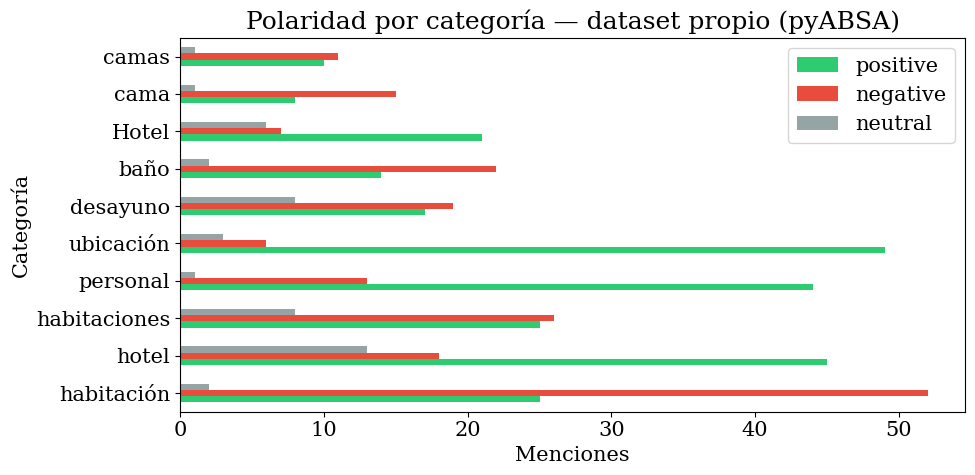

In [31]:
cat_counts = {}
for colomn in df_profiles.columns:
    if colomn != "review":
        mentions = df_profiles[colomn].dropna()
        all_pols = [p for pols in mentions for p in pols]
        cat_counts[colomn] = {
            'n_reviews': len(mentions),
            'positive': all_pols.count('positive'),
            'negative': all_pols.count('negative'),
            'neutral': all_pols.count('neutral'),
        }

df_summary = pd.DataFrame(cat_counts).T
df_summary.index.name = 'Categoría'
df_summary = df_summary.sort_values('n_reviews', ascending=False)
display(df_summary)

# Visualizar las categorias con más menciones y su polaridad
df_summary = df_summary.sort_values('n_reviews', ascending=False)
df_summary = df_summary.head(10)  # mostrar solo top 10 categorías  
fig, ax = plt.subplots(figsize=(10, 5))
df_summary[['positive', 'negative', 'neutral']].plot(
    kind='barh', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6']
)
ax.set_title('Polaridad por categoría — dataset propio (pyABSA)')
ax.set_xlabel('Menciones')
plt.tight_layout()
plt.show()